<h1>Ecom Quant Lab — E-commerce Decision Intelligence</h1>
<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🎯 KPI Decision Engine — Scale, Hold eller Kill?</h2>
<p>Quantitative Training Lab — Februar 2026</p>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🎯 Learning Objectives</h2>
<ul>
  <li>Forstå <b>hvorfor naive beslutningsregler er farlige</b> — og hva som kan gå galt</li>
  <li>Forklare <b>statistical confidence</b> og hvorfor sample size bestemmer pålitelighet</li>
  <li>Beregne <b>CPA ratio</b> — den normaliserte metricen for alle produkter</li>
  <li>Identifisere de tre <b>beslutningssonene</b>: Scale, Hold og Kill — med buffere</li>
  <li>Forstå <b>to-lags beslutningslogikk</b>: confidence gate → performance gate</li>
  <li>Anvende <b>KPIDecisionEngine</b> på reelle kampanje-scenarier</li>
</ul>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🗺️ Oversikt</h2>
<ul>
  <li><b>Del 1 — Problemstilling:</b> Hvorfor er «if CPA &lt; max_CPA: scale» en dårlig idé?</li>
  <li><b>Del 2 — Statistical confidence:</b> Sample size og datagrunnlag</li>
  <li><b>Del 3 — CPA ratio:</b> Normalisert sammenligning på tvers av produkter</li>
  <li><b>Del 4 — Beslutningszoner:</b> Kill / Hold / Scale med buffere</li>
  <li><b>Del 5 — To-lags logikk:</b> Confidence gate → Performance gate</li>
  <li><b>Del 6 — Kampanje-livssyklus:</b> Beslutninger over tid</li>
  <li><b>Implementering:</b> KPIDecisionEngine live med visualiseringer</li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 1 — Problemet med naive beslutninger</h2>
<p>De fleste tenker slik når de evaluerer en annonsekampanje:</p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
NAIV LOGIKK:

  if CPA &lt; max_CPA:
      beslutning = "SCALE"
  else:
      beslutning = "KILL"
</pre>
<p>Dette høres logisk ut — men det er <b>fundamentalt feil</b>.</p>
<p><b>Problemet — et konkret eksempel:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Max CPA: 458 kr

Uke 1 — DAG 3:
  Du har brukt 600 kr på ads
  Du fikk 3 salg
  CPA = 600 / 3 = 200 kr ← ser fantastisk ut!
  Naiv beslutning: SCALE → dobler budsjettet

Uke 2 — etter 50 salg:
  CPA er nå 470 kr ← over max!
  Du har allerede skalert og tapt penger
</pre>
<p><b>Hva skjedde?</b> De 3 første salgene var <b>flaks</b>, ikke signal. Med så lite data
kan CPA variere enormt fra den sanne verdien.</p>
<p style="background:rgba(255,99,71,0.1); padding:10px; border-left:4px solid rgba(255,99,71,0.5); border-radius:3px">
  ⚠️ <b>Kritisk innsikt:</b> En god CPA med 3 salg er meningsløs støy.
  En god CPA med 50 salg er et pålitelig signal.
  Naive regler skiller ikke mellom disse to.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 2 — Statistical Confidence (Datagrunnlag)</h2>
<p><b>Confidence</b> handler om ett spørsmål: <i>Kan jeg stole på dette tallet?</i></p>
<p>Jo flere konverteringer du har, desto nærmere er din observerte CPA den <b>sanne CPA</b>.
Med få observasjoner er det stor variasjon — med mange observasjoner stabiliserer den seg.</p>
<p><b>Tre konfidens-nivåer:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
LOW    → &lt; 10 konverteringer
         Ikke nok data. Ikke ta beslutninger uansett CPA.
         Regel: alltid HOLD.

MEDIUM → 10–30 konverteringer
         Nok data for forsiktige beslutninger.
         Regel: KILL ved klart tap, SCALE ved klart overskudd.

HIGH   → &gt; 30 konverteringer
         Solid datagrunnlag. Pålitelige beslutninger.
         Regel: alle beslutninger er gyldige.
</pre>
<p><b>Formelen:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
if konverteringer &lt; min_conversions:          → LOW
elif konverteringer &lt; min_conversions × 3:    → MEDIUM
else:                                          → HIGH

Standard: min_conversions = 10
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Hvorfor 10 og 30?</b> Det er tommelfingerregler basert på statistisk variasjon
  i konverteringsdata. Med &lt;10 observasjoner er standardavviket for høyt til at
  gjennomsnittet betyr noe. Du kan justere disse etter ditt volum.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 3 — CPA Ratio (normalisert sammenligning)</h2>
<p>I stedet for å sammenligne absolutte CPA-verdier bruker vi en <b>ratio</b>.
Dette gjør logikken produkt-agnostisk — den fungerer uansett prispunkt.</p>
<p><b>Formelen:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
CPA Ratio = Faktisk CPA / Max CPA
</pre>
<p><b>Hva betyr ratio-verdiene?</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Ratio = 0.44  →  CPA er 44% av max → klart lønnsom
Ratio = 0.90  →  CPA er 90% av max → marginalt lønnsom
Ratio = 1.00  →  CPA = max CPA     → break-even (null profit)
Ratio = 1.20  →  CPA er 20% over   → taper penger
Ratio = 1.50  →  CPA er 50% over   → betydelige tap
</pre>
<p><b>Eksempel:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Max CPA: 458 kr
Faktisk CPA: 200 kr

CPA Ratio = 200 / 458 = 0.437

→ CPA er bare 44% av max → solid overskudd
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Fordelen med ratio:</b> Samme logikk fungerer for et produkt med max CPA 50 kr
  og et med max CPA 2000 kr. Du trenger ikke justere terskler per produkt.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 4 — Beslutningszoner (Kill / Hold / Scale)</h2>
<p>Beslutningslogikken er <b>ikke binær</b> (god/dårlig). Den har tre soner med buffere.</p>
<p><b>Sonene basert på CPA Ratio:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
┌─────────────────────────────────────────────────────┐
│  Ratio &lt; 0.90   →  🟢 SCALE  (klart lønnsom)        │
│  0.90 – 1.20    →  🟡 HOLD   (marginalt / usikkert) │
│  Ratio &gt; 1.20   →  🔴 KILL   (klart ulønnsom)       │
└─────────────────────────────────────────────────────┘
</pre>
<p><b>Hvorfor buffere?</b> CPA varierer naturlig fra uke til uke. Bufferne forhindrer:
<ul>
  <li><b>For tidlig scaling</b> — CPA på 95% av max er marginalt, ikke «bra nok»</li>
  <li><b>For tidlig killing</b> — CPA på 105% av max kan skyldes én dyr uke, ikke trenden</li>
</ul>
</p>
<p><b>I NOK for vårt kaffetrakter-produkt (max CPA = 458 kr):</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
SCALE zone: CPA &lt; 412 kr  (90% av 458)
HOLD zone:  412 – 549 kr
KILL zone:  CPA &gt; 549 kr  (120% av 458)
</pre>
<p style="background:rgba(255,215,0,0.1); padding:10px; border-left:4px solid rgba(255,215,0,0.7); border-radius:3px">
  ⚠️ <b>Du kan justere terskler:</b> kill_threshold=1.2 og scale_threshold=0.9 er defaults.
  Et produkt med veldig stabil CPA kan bruke tettere buffere (1.1 / 0.95).
  Et volatilt produkt trenger videre buffere (1.3 / 0.85).
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 5 — To-lags beslutningslogikk</h2>
<p>Motoren evaluerer kampanjen i <b>to sekvensielle lag</b>:</p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
LAG 1 — Konfidens-gate:
  Har vi nok data til å beslutte i det hele tatt?

  if confidence == LOW:
      return HOLD  ← alltid, uansett CPA

LAG 2 — Ytelse-gate (kun nådd hvis confidence ≥ MEDIUM):
  Er CPA innenfor akseptable soner?

  if ratio &gt; 1.20:                          → KILL
  if ratio &lt; 0.90 AND confidence ≥ MEDIUM:  → SCALE
  else:                                      → HOLD
</pre>
<p><b>Beslutningsmatrise:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
                │  LOW conf  │ MEDIUM conf │  HIGH conf
────────────────┼────────────┼─────────────┼───────────
Ratio &gt; 1.20   │    HOLD    │    KILL     │    KILL
Ratio 0.90–1.20 │    HOLD    │    HOLD     │    HOLD
Ratio &lt; 0.90   │    HOLD    │    SCALE    │    SCALE
</pre>
<p style="background:rgba(255,99,71,0.1); padding:10px; border-left:4px solid rgba(255,99,71,0.5); border-radius:3px">
  ⚠️ <b>Legg merke til:</b> Med LOW confidence er svaret alltid HOLD — selv om CPA
  er 10× over max. Denne disiplinen er det som skiller kvantitativ analyse
  fra emosjonelle panikk-beslutninger.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 6 — Kampanje-livssyklus</h2>
<p>Beslutninger skjer ikke isolert — de skjer <b>over tid</b> ettersom data akkumuleres.</p>
<p><b>Typisk kampanje-livssyklus:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Dag 1–3:   2–5 konverteringer   → LOW confidence  → HOLD
           (uansett hva CPA viser — det er støy)

Dag 4–14:  10–25 konverteringer → MEDIUM confidence → første beslutning
           (forsiktig: KILL hvis klart tap, SCALE hvis klart overskudd)

Dag 14+:   30+ konverteringer   → HIGH confidence → full beslutningsevne
           (alle tre utfall er gyldige og pålitelige)
</pre>
<p><b>Hva dette betyr i praksis:</b></p>
<ul>
  <li>Start alltid en ny kampanje med lavt budsjett — nok til å samle data</li>
  <li>Ikke skaler de første dagene uansett hvor bra det ser ut</li>
  <li>Ikke drep kampanjen etter 2 dyre salg</li>
  <li>La motoren beslutte basert på data, ikke magefølelse</li>
</ul>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Tommelfingerregel:</b> Bruk minimum 500–1000 kr i ads for å samle
  nok data til MEDIUM confidence. Behandle dette som «kostnaden for informasjon» —
  ikke som tap.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 1: Imports og Setup</h2>
<p>Vi importerer begge modulene vi har bygget og setter opp et realistisk produktscenario.</p>

In [1]:
# Standard biblioteker for visualisering og numerisk analyse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Sett plotting-stil lik break-even notebooken
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Importer våre egne moduler fra src/
import sys
sys.path.append('../src')
from break_even import BreakEvenCalculator
from kpi_engine import KPIDecisionEngine

print("✅ Imports successful!")

✅ Imports successful!


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 2: Sett opp engine</h2>
<p>Vi bruker samme kaffetrakter-produkt som i break-even notebooken.
KPIDecisionEngine tar en ferdig BreakEvenCalculator og henter max_cpa automatisk.</p>

In [2]:
# Samme produkt som i break-even notebooken
calc = BreakEvenCalculator(
    sale_price=799,
    product_cost=250,
    shipping_cost=65,
    payment_fee_percent=0.029,
    payment_fee_fixed=3
)

# Bygg decision engine på toppen av calculatoren
engine = KPIDecisionEngine(calc, min_conversions=10)

# Vis hva engine har hentet automatisk
print("=" * 50)
print("📊 PRODUKTØKONOMI (hentet fra BreakEvenCalculator)")
print("=" * 50)
print(f"Max CPA:         {engine.max_cpa:.0f} NOK")
print(f"Break-even ROAS: {engine.breakeven_roas:.2f}x")
print("-" * 50)
print("📍 BESLUTNINGSSONER")
print(f"SCALE zone: CPA < {engine.max_cpa * engine.scale_threshold:.0f} NOK")
print(f"HOLD zone:  {engine.max_cpa * engine.scale_threshold:.0f} – {engine.max_cpa * engine.kill_threshold:.0f} NOK")
print(f"KILL zone:  CPA > {engine.max_cpa * engine.kill_threshold:.0f} NOK")
print("=" * 50)

📊 PRODUKTØKONOMI (hentet fra BreakEvenCalculator)
Max CPA:         458 NOK
Break-even ROAS: 1.75x
--------------------------------------------------
📍 BESLUTNINGSSONER
SCALE zone: CPA < 412 NOK
HOLD zone:  412 – 549 NOK
KILL zone:  CPA > 549 NOK


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — Problemet med liten sample</h2>
<p>La oss demonstrere <b>hvorfor sample size er kritisk</b>.
Vi simulerer samme kampanje (med kjent sann CPA) observert med ulik datamengde.</p>

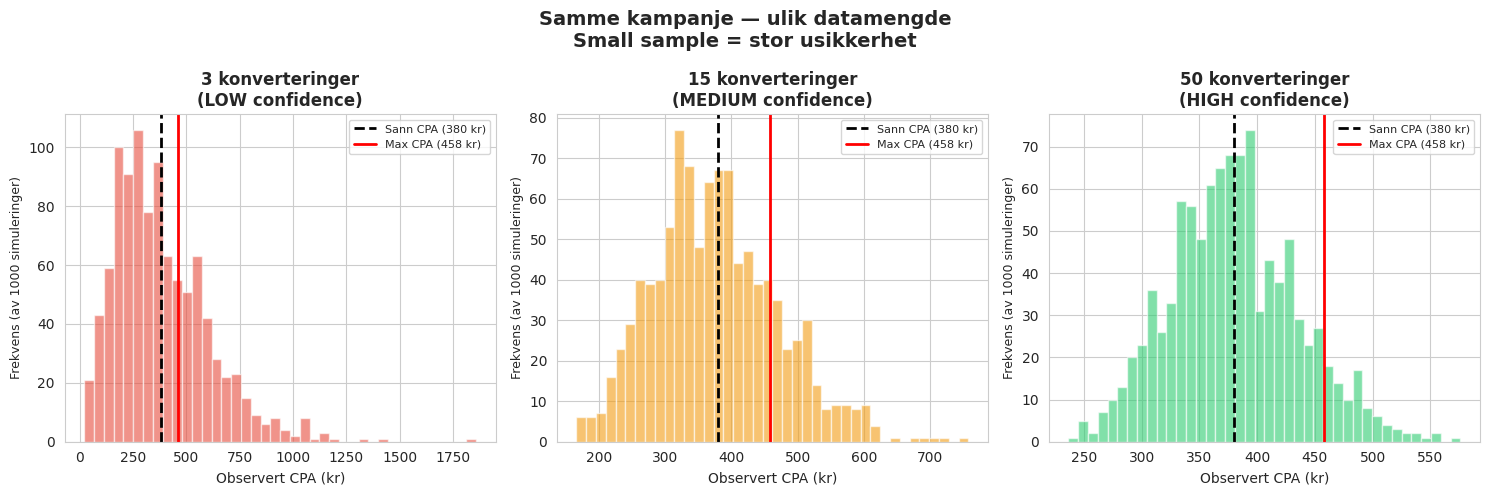

💡 Med 3 salg: observert CPA kan variere fra ~100 til ~900 kr — rent tilfeldig
💡 Med 50 salg: observert CPA konvergerer mot sann verdi på 380 kr


In [3]:
# Simuler observert CPA fra en kampanje med kjent sann CPA
np.random.seed(42)
true_cpa = 380  # sann CPA — lønnsom (under max 458 kr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sample_sizes = [3, 15, 50]
titles = [
    '3 konverteringer\n(LOW confidence)',
    '15 konverteringer\n(MEDIUM confidence)',
    '50 konverteringer\n(HIGH confidence)'
]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, n, title, color in zip(axes, sample_sizes, titles, colors):
    # Simuler 1000 gjentakelser av kampanjen med n konverteringer
    observed_cpas = [np.random.exponential(true_cpa, n).mean() for _ in range(1000)]

    ax.hist(observed_cpas, bins=40, color=color, alpha=0.6, edgecolor='white')
    ax.axvline(true_cpa, color='black', linestyle='--', linewidth=2,
               label=f'Sann CPA ({true_cpa} kr)')
    ax.axvline(engine.max_cpa, color='red', linestyle='-', linewidth=2,
               label=f'Max CPA ({engine.max_cpa:.0f} kr)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Observert CPA (kr)', fontsize=10)
    ax.set_ylabel('Frekvens (av 1000 simuleringer)', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle(
    'Samme kampanje — ulik datamengde\nSmall sample = stor usikkerhet',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("💡 Med 3 salg: observert CPA kan variere fra ~100 til ~900 kr — rent tilfeldig")
print("💡 Med 50 salg: observert CPA konvergerer mot sann verdi på 380 kr")

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — CPA Beslutningssoner</h2>
<p>Her visualiserer vi de tre sonene langs CPA-aksen for vårt produkt.</p>

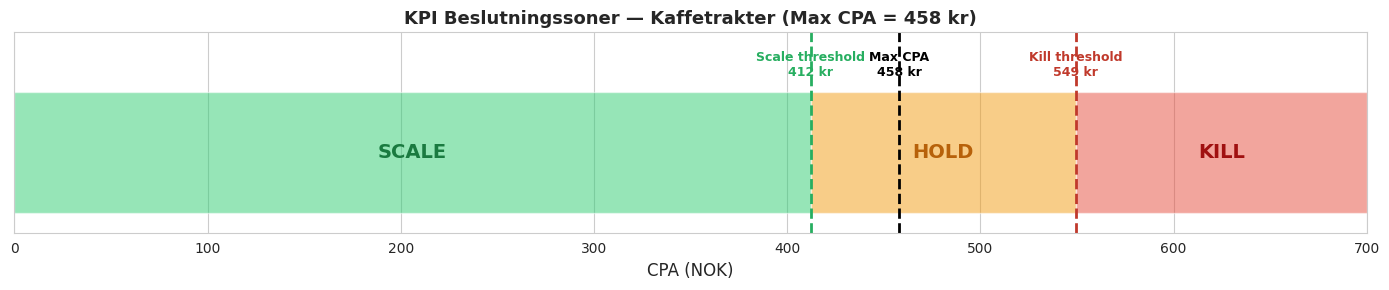

In [4]:
fig, ax = plt.subplots(figsize=(14, 3))

max_cpa    = engine.max_cpa
kill_line  = max_cpa * engine.kill_threshold   # 549 kr
scale_line = max_cpa * engine.scale_threshold  # 412 kr
x_max      = 700

# Tegn de tre sonene som horisontale felt
ax.barh(0, scale_line,             height=0.6, color='#2ecc71', alpha=0.5)
ax.barh(0, kill_line - scale_line, height=0.6, color='#f39c12', alpha=0.5,
        left=scale_line)
ax.barh(0, x_max - kill_line,      height=0.6, color='#e74c3c', alpha=0.5,
        left=kill_line)

# Sentrer sone-labels (plain tekst med matchende farge)
ax.text(scale_line / 2,               0, 'SCALE', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#1a7a40')
ax.text((scale_line + kill_line) / 2, 0, 'HOLD',  ha='center', va='center',
        fontsize=14, fontweight='bold', color='#b7610a')
ax.text((kill_line + x_max) / 2,      0, 'KILL',  ha='center', va='center',
        fontsize=14, fontweight='bold', color='#a01010')

# Markér viktige terskler
for x, label, color in [
    (max_cpa,    f'Max CPA\n{max_cpa:.0f} kr',         'black'),
    (scale_line, f'Scale threshold\n{scale_line:.0f} kr', '#27ae60'),
    (kill_line,  f'Kill threshold\n{kill_line:.0f} kr',   '#c0392b'),
]:
    ax.axvline(x, color=color, linewidth=2, linestyle='--')
    ax.text(x, 0.38, label, ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlim(0, x_max)
ax.set_ylim(-0.4, 0.6)
ax.set_yticks([])
ax.set_xlabel('CPA (NOK)', fontsize=12)
ax.set_title(
    'KPI Beslutningssoner — Kaffetrakter (Max CPA = 458 kr)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 3: Alle fire scenarier</h2>
<p>Vi kjører alle fire mulige utfall gjennom motoren og ser rapporten for hvert.</p>

In [5]:
# Fire scenarier som dekker alle beslutningsutfall
scenarios = [
    ("Scenario A — For lite data (LOW confidence)",   2000,  4, 3200),
    ("Scenario B — Klart ulønnsom (KILL)",            9000, 15, 7000),
    ("Scenario C — Marginalt lønnsom (HOLD)",         6600, 15, 9500),
    ("Scenario D — Klart lønnsom (SCALE)",            5000, 25, 12000),
]

for label, spend, conv, rev in scenarios:
    print(f"\n{'─'*56}")
    print(f"  {label}")
    print(f"  Spend: {spend:,} NOK  |  Konv: {conv}  |  Rev: {rev:,} NOK")
    engine.get_decision_report(spend, conv, rev)


────────────────────────────────────────────────────────
  Scenario A — For lite data (LOW confidence)
  Spend: 2,000 NOK  |  Konv: 4  |  Rev: 3,200 NOK
  KPI DECISION REPORT
  Decision:    ⏸  HOLD
  Confidence:  LOW
--------------------------------------------------------
  Insufficient data — need at least 10 conversions
  for a reliable signal. Current CPA: 500 NOK vs max
  458 NOK. Keep running and gather more data.
--------------------------------------------------------
  CAMPAIGN METRICS
  Conversions: 4
  Spend:            2,000 NOK
  Revenue:          3,200 NOK
  Actual CPA:         500 NOK
  Max CPA:            458 NOK
  CPA ratio:       109.2% of max
  Actual ROAS:       1.60x
  B/E ROAS:          1.75x

────────────────────────────────────────────────────────
  Scenario B — Klart ulønnsom (KILL)
  Spend: 9,000 NOK  |  Konv: 15  |  Rev: 7,000 NOK
  KPI DECISION REPORT
  Decision:    🛑 KILL
  Confidence:  MEDIUM
--------------------------------------------------------
  CPA 

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — Scenarie-sammenligning</h2>
<p>La oss plotte alle fire scenarier i CPA-sone-diagrammet for visuell sammenligning.</p>

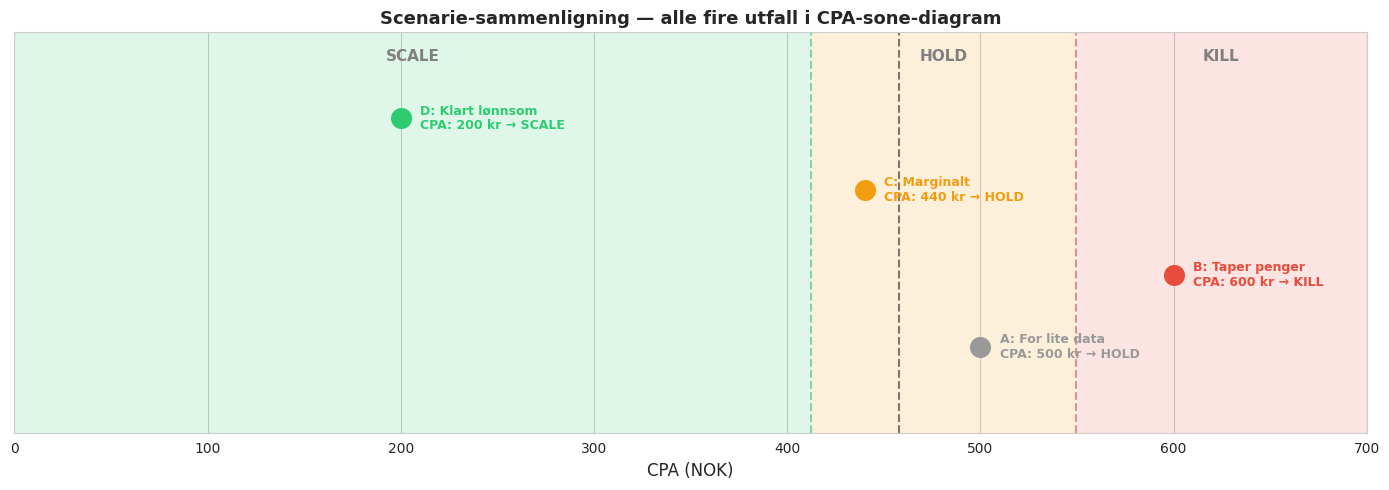

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

# Tegn sone-bakgrunn (samme som forrige visualisering)
ax.barh(0, scale_line,             height=4, color='#2ecc71', alpha=0.15)
ax.barh(0, kill_line - scale_line, height=4, color='#f39c12', alpha=0.15,
        left=scale_line)
ax.barh(0, x_max - kill_line,      height=4, color='#e74c3c', alpha=0.15,
        left=kill_line)

# Terskler
ax.axvline(max_cpa,    color='black',   linewidth=1.5, linestyle='--', alpha=0.5)
ax.axvline(scale_line, color='#27ae60', linewidth=1.5, linestyle='--', alpha=0.5)
ax.axvline(kill_line,  color='#c0392b', linewidth=1.5, linestyle='--', alpha=0.5)

# Plot hvert scenarie som en horisontal linje + punkt
scenario_data = [
    ("A: For lite data",   2000,  4, 3200,  -0.8, '#999999'),
    ("B: Taper penger",    9000, 15, 7000,  -0.3, '#e74c3c'),
    ("C: Marginalt",       6600, 15, 9500,   0.3, '#f39c12'),
    ("D: Klart lønnsom",   5000, 25, 12000,  0.8, '#2ecc71'),
]

for label, spend, conv, rev, y_pos, color in scenario_data:
    cpa = spend / conv if conv > 0 else 0
    conf = engine._calculate_confidence(conv)
    decision, _ = engine._make_decision(cpa, conf) if conv > 0 else ('HOLD', '')

    ax.scatter([cpa], [y_pos], s=200, color=color, zorder=5)
    ax.text(cpa + 10, y_pos, f"{label}\nCPA: {cpa:.0f} kr → {decision}",
            va='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlim(0, x_max)
ax.set_ylim(-1.4, 1.4)
ax.set_yticks([])
ax.set_xlabel('CPA (NOK)', fontsize=12)
ax.set_title('Scenarie-sammenligning — alle fire utfall i CPA-sone-diagram',
             fontsize=13, fontweight='bold')

# Sone-labels
for x_center, label in [
    (scale_line / 2,              'SCALE'),
    ((scale_line + kill_line) / 2, 'HOLD'),
    ((kill_line + x_max) / 2,     'KILL'),
]:
    ax.text(x_center, 1.2, label, ha='center', fontsize=11,
            fontweight='bold', color='grey')

plt.tight_layout()
plt.show()

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">✅ Key Takeaways</h2>
<ul>
  <li><b>Naive if/else regler</b> er farlige — de ignorerer datakvalitet</li>
  <li><b>Statistical confidence</b> er laget 1 — uten nok data tar du aldri en beslutning</li>
  <li><b>CPA ratio</b> normaliserer logikken slik at den fungerer for alle produkter</li>
  <li><b>Buffere</b> rundt break-even absorberer naturlig variasjon i CPA</li>
  <li><b>To-lags logikk</b> er mer robust enn én enkelt regel — og lettere å forklare</li>
  <li><b>HOLD er ikke passivitet</b> — det er informert tålmodighet mens du samler data</li>
  <li>Du kan <b>justere terskler</b> (min_conversions, kill_threshold, scale_threshold) per produkt</li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">❓ Refleksjonsspørsmål</h2>
<ol>
  <li>Hvorfor er LOW confidence alltid HOLD — selv om CPA er 10× under max?</li>
  <li>Forklar med egne ord hva CPA ratio er og hvilken fordel den gir over absolutt CPA.</li>
  <li>Du har 20 konverteringer og CPA er 95% av max. Hva besluttes og hvorfor?</li>
  <li>Hva skjer med beslutningssonene hvis du setter kill_threshold=1.5 og scale_threshold=0.8?</li>
  <li>Hvorfor bør en ny kampanje alltid starte med lavt budsjett de første dagene?</li>
  <li>En kampanje har MEDIUM confidence og CPA ratio 0.85 — hva er beslutningen?</li>
</ol>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🎯 Neste steg</h2>
<p>I neste notebook skal vi:</p>
<ul>
  <li>Bygge <b>Ad Campaign Simulator</b> — simuler kampanjeresultater med Monte Carlo</li>
  <li>Teste <b>hva som skjer over tid</b> — CPA-trender og periodisk re-evaluering</li>
  <li>Kombinere <b>BreakEvenCalculator + KPIDecisionEngine</b> i én samlet workflow</li>
</ul>